<a href="https://colab.research.google.com/github/jferreira04-cloud/Calculo_num-rico_lobosco/blob/main/ATIVIDADE_COMPUTACIONAL_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova seção
Aluno: José Luiz de Oliveira Ferreira - João Paulo Braga Correia / Turma: NB / Data: (26/08/2026)
       


x1 = 3.14159265 
n = 0 Truncado: 3  Arredondado: 3
   Ea: 0.14159265 Er: 0.04507034  E%: 4.507034%
n = 1 Truncado: 3.1  Arredondado: 3.1
   Ea: 0.04159265 Er: 0.01323935  E%: 1.323935%
n = 2 Truncado: 3.14  Arredondado: 3.14
   Ea: 0.00159265 Er: 0.00050696  E%: 0.050696%
n = 3 Truncado: 3.141  Arredondado: 3.142
   Ea: 0.00059265 Er: 0.00018865  E%: 0.018865%
n = 4 Truncado: 3.1415  Arredondado: 3.1416
   Ea: 0.00009265 Er: 0.00002949  E%: 0.002949%

x2 = 98.76543 
n = 0 Truncado: 98  Arredondado: 99
   Ea: 0.76543000 Er: 0.00774998  E%: 0.774998%
n = 1 Truncado: 98.7  Arredondado: 98.8
   Ea: 0.06543000 Er: 0.00066248  E%: 0.066248%
n = 2 Truncado: 98.76  Arredondado: 98.77
   Ea: 0.00543000 Er: 0.00005498  E%: 0.005498%
n = 3 Truncado: 98.765  Arredondado: 98.765
   Ea: 0.00043000 Er: 0.00000435  E%: 0.000435%
n = 4 Truncado: 98.7654  Arredondado: 98.7654
   Ea: 0.00003000 Er: 0.00000030  E%: 0.000030%

x3 = 0.00498765 
n = 0 Truncado: 0  Arredondado: 0
   Ea: 0.00498765 Er: 1.0000

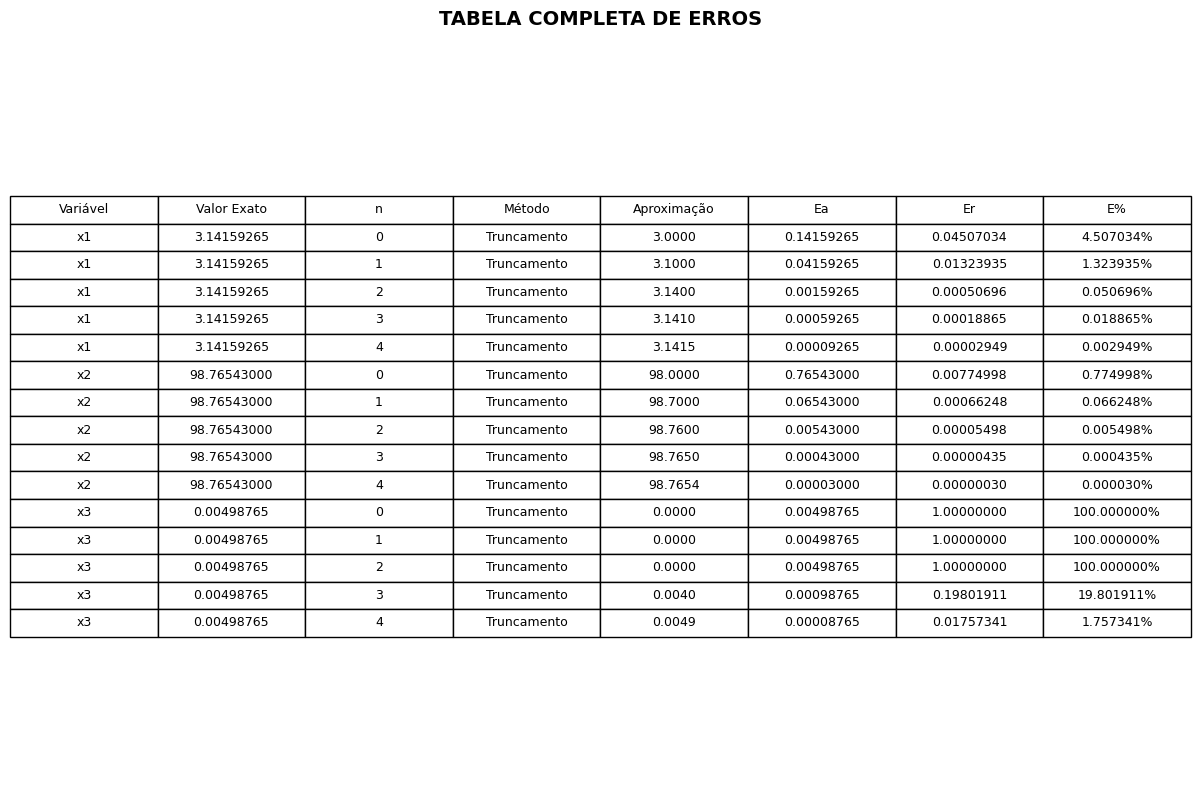

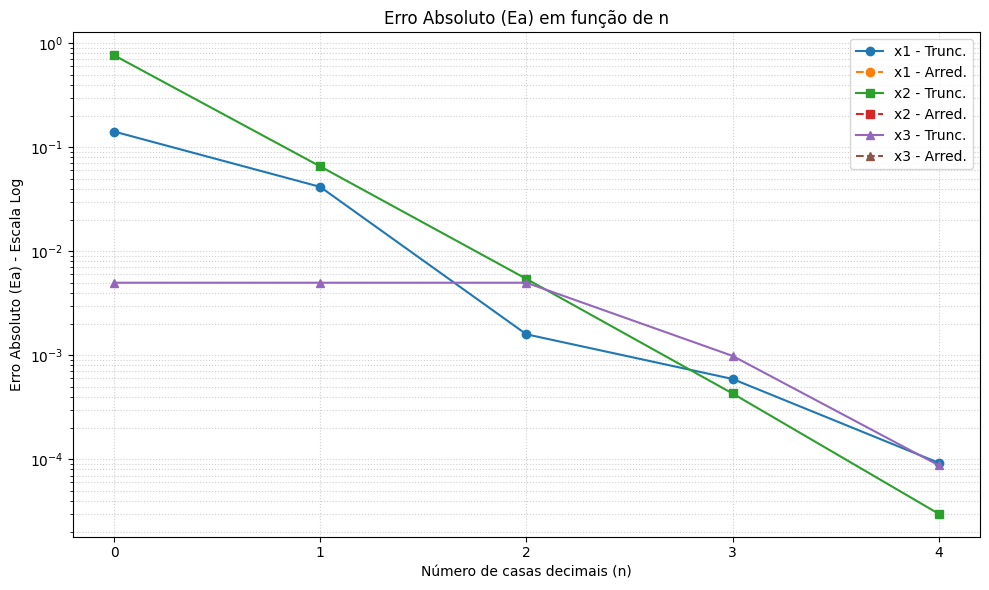

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# Define uma função para truncar um número em determinada quantidade de casas.
def truncar(numero, casas):
    fator = 10**casas
 # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

# 2. Dados
valores = {"x1": 3.14159265, "x2": 98.76543, "x3": 0.00498765}
casas_n = [0, 1, 2, 3, 4]

resultados = []

# 3. Processamento de todos os valores e casas (n)
for nome_x, x_exato in valores.items():
    print(f"\n{nome_x} = {x_exato} ")

    for n in casas_n:
        # A FUNÇÃO TRUNCAR E O ROUND NATIVO:
        v_trunc = truncar(x_exato, n)
        v_arred = round(x_exato, n)

        print(f"n = {n} Truncado: {v_trunc:.{n}f}  Arredondado: {v_arred:.{n}f}")


# PARTE A2) Erros do Truncamento
        Ea_trunc = abs(x_exato - v_trunc)
        Er_trunc = Ea_trunc / abs(x_exato)
        Ep_trunc = Er_trunc * 100

        print(
            f"   Ea: {Ea_trunc:.8f} Er: {Er_trunc:.8f}  E%: {Ep_trunc:.6f}%"
        )

        resultados.append(
            {
                "Variável": nome_x,
                "Valor Exato": x_exato,
                "n": n,
                "Método": "Truncamento",
                "Aproximação": v_trunc,
                "Ea": Ea_trunc,
                "Er": Er_trunc,
                "E%": Ep_trunc,
            }
        )
     # Parte A3)


   # 4. TABELA COMPLETA (Item 3) em linha de código
df = pd.DataFrame(resultados)
print("\n" "TABELA COMPLETA " )
print(df.to_string(index=False))

  # 4. TABELA COMPLETA (Item 3) em imagem
df = pd.DataFrame(resultados)

# Cria uma figura para desenhar a tabela
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis("off")  # Esconde os eixos do gráfico

# Formata os números da tabela para não ficarem com dígitos infinitos na imagem
df_formatado = df.copy()
df_formatado["Valor Exato"] = df_formatado["Valor Exato"].apply(
    lambda x: f"{x:.8f}"
)
df_formatado["Aproximação"] = df_formatado["Aproximação"].apply(
    lambda x: f"{x:.4f}"
)
df_formatado["Ea"] = df_formatado["Ea"].apply(lambda x: f"{x:.8f}")
df_formatado["Er"] = df_formatado["Er"].apply(lambda x: f"{x:.8f}")
df_formatado["E%"] = df_formatado["E%"].apply(lambda x: f"{x:.6f}%")

# Desenha a tabela na imagem
tabela = ax.table(
    cellText=df_formatado.values,
    colLabels=df_formatado.columns,
    cellLoc="center",
    loc="center",
)

# Ajusta o tamanho da fonte e escala das células
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.4)

plt.title("TABELA COMPLETA DE ERROS", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()

# Salva a imagem no seu computador (opcional)
plt.savefig("tabela_resultados.png", dpi=300, bbox_inches="tight")

# Exibe a imagem da tabela na tela
plt.show()



# 5. GRÁFICO LOGARÍTMICO (Item 4)
plt.figure(figsize=(10, 6))
estilos = {"x1": "o", "x2": "s", "x3": "^"}

for nome_x in valores.keys():
    df_trunc = df[(df["Variável"] == nome_x) & (df["Método"] == "Truncamento")]
    plt.plot(
        df_trunc["n"],
        df_trunc["Ea"],
        marker=estilos[nome_x],
        linestyle="-",
        label=f"{nome_x} - Trunc.",
    )

    df_arr = df[(df["Variável"] == nome_x) & (df["Método"] == "Arredondamento")]
    plt.plot(
        df_arr["n"],
        df_arr["Ea"],
        marker=estilos[nome_x],
        linestyle="--",
        label=f"{nome_x} - Arred.",
    )

plt.yscale("log")
plt.xlabel("Número de casas decimais (n)")
plt.ylabel("Erro Absoluto (Ea) - Escala Log")
plt.title("Erro Absoluto (Ea) em função de n")
plt.xticks(casas_n)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
import math
import statistics

#B1
# Define uma função para truncar um número em determinada quantidade de casas.
def truncar(dados, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(dados * fator) / fator

dados = [121.7, 120.4, 122.1, 119.8, 121.2,
         120.9, 122.4, 121.0, 120.2, 121.5]

originais = dados
arredondados = [round(x) for x in dados]
truncados = [truncar(x, 0) for x in dados]


# Função para calcular as estatísticas
def estatisticas(dados):
    media = statistics.mean(dados)
    minimo = min(dados)
    maximo = max(dados)
    amplitude = maximo - minimo
    desvio = statistics.stdev(dados)

    return media, minimo, maximo, amplitude, desvio


# Calculando as estatísticas
estat_orig = estatisticas(originais)
estat_arred = estatisticas(arredondados)
estat_trunc = estatisticas(truncados)


# Exibindo as séries
print("Dados originais:", originais)
print("Dados arredondados:", arredondados)
print("Dados truncados:", truncados)


# Exibindo as estatísticas
print("\n--- DADOS ORIGINAIS ---")
print("Média:", estat_orig[0])
print("Mínimo:", estat_orig[1])
print("Máximo:", estat_orig[2])
print("Amplitude:", estat_orig[3])
print("Desvio-padrão:", estat_orig[4])

print("\n--- DADOS ARREDONDADOS ---")
print("Média:", estat_arred[0])
print("Mínimo:", estat_arred[1])
print("Máximo:", estat_arred[2])
print("Amplitude:", estat_arred[3])
print("Desvio-padrão:", estat_arred[4])

print("\n--- DADOS TRUNCADOS ---")
print("Média:", estat_trunc[0])
print("Mínimo:", estat_trunc[1])
print("Máximo:", estat_trunc[2])
print("Amplitude:", estat_trunc[3])
print("Desvio-padrão:", estat_trunc[4])


# Média de referência
media_ref = estat_orig[0]


# Erros da média arredondada
erro_arred = abs(estat_arred[0] - media_ref)
erro_rel_arred = erro_arred / abs(media_ref)
erro_perc_arred = erro_rel_arred * 100


# Erros da média truncada
erro_trunc = abs(estat_trunc[0] - media_ref)
erro_rel_trunc = erro_trunc / abs(media_ref)
erro_perc_trunc = erro_rel_trunc * 100


# Exibindo os erros
print("\n--- ERROS ---")

print("\nMédia arredondada:")
print("Erro absoluto:", erro_arred)
print("Erro relativo:", erro_rel_arred)
print("Erro percentual:", erro_perc_arred, "%")

print("\nMédia truncada:")
print("Erro absoluto:", erro_trunc)
print("Erro relativo:", erro_rel_trunc)
print("Erro percentual:", erro_perc_trunc, "%")

Dados originais: [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
Dados arredondados: [122, 120, 122, 120, 121, 121, 122, 121, 120, 122]
Dados truncados: [121.0, 120.0, 122.0, 119.0, 121.0, 120.0, 122.0, 121.0, 120.0, 121.0]

--- DADOS ORIGINAIS ---
Média: 121.12
Mínimo: 119.8
Máximo: 122.4
Amplitude: 2.6000000000000085
Desvio-padrão: 0.8337332373793856

--- DADOS ARREDONDADOS ---
Média: 121.1
Mínimo: 120
Máximo: 122
Amplitude: 2
Desvio-padrão: 0.8755950357709131

--- DADOS TRUNCADOS ---
Média: 120.7
Mínimo: 119.0
Máximo: 122.0
Amplitude: 3.0
Desvio-padrão: 0.9486832980505138

--- ERROS ---

Média arredondada:
Erro absoluto: 0.020000000000010232
Erro relativo: 0.0001651254953765706
Erro percentual: 0.01651254953765706 %

Média truncada:
Erro absoluto: 0.4200000000000017
Erro relativo: 0.003467635402906223
Erro percentual: 0.3467635402906223 %
